# Protein Model Evaluation and Comparison

This notebook provides a step-by-step evaluation and comparison of two trained protein prediction models. The workflow includes loading models, preparing data, optimizing thresholds, evaluating performance on residue and domain levels, and analyzing confusion patterns between protein families.

**Outline:**
1. Import Required Libraries
2. Load Trained Models
3. Load and Prepare Datasets
4. Obtain Model Predictions and Probabilities (Softmax)
5. Find Optimal Threshold on Train & Validation Sets
6. Evaluate Per-Class Metrics (Accuracy, Precision, Recall, F1)
7. Test Set Evaluation: Predictions and Metrics
8. Measure Inference Runtime and GPU Usage
9. Calculate Model Size (Number of Parameters)
10. Compute Confusion Matrix for Residue-Level Predictions
11. Domain-Level Prediction Evaluation
12. Analyze Confusion Patterns Between Protein Families

In [97]:
# Create a directory for saving plots if it doesn't exist
import os
PLOT_DIR = "plots"
os.makedirs(PLOT_DIR, exist_ok=True)

## 1. Import Required Libraries
Import all necessary libraries for data handling, model loading, evaluation, and visualization.

In [1]:
# Standard libraries
import os
import sys
import time
import tracemalloc
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, ConcatDataset

# Sklearn metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Custom imports (adjust paths as needed)
sys.path.append(os.path.abspath('../models'))
from Dataset import ProteinCSVWindowDataset, ProteinEmbeddingWithLabelsDataset,  collate_fn_window
from original import OriginalModel, OriginalModelLarger
from small import SmallModel

random.seed(42)

## 2. Load Trained Models
Load both final trained models from their .pth files and set them to evaluation mode.

In [ ]:
# Specify model checkpoint paths

MODEL2_PATH = './checkpoints/original_bs8_lr3e-04_ep15_20250623_232208.pth'  # EMB
MODEL1_PATH = './checkpoints/original_bs8_lr3e-03_ep15_20250622_212924.pth'     # onehot
MODEL3_PATH = r"C:\Users\danei\OneDrive\workspace\ProteinPrediction\src\checkpoints\original_bs1_lr1e-05_ep15_20250622_011338.pth"

# Instantiate models
#TODO maybe get num_classes from dataset or config
model2 = OriginalModel(num_classes=58, channels=512, input_size=1024)
model1 = OriginalModel(num_classes=58, channels=512)
model3 = OriginalModel(num_classes=58, channels=512)

# Load weights
model1.load_state_dict(torch.load(MODEL1_PATH, map_location='cuda'))
model2.load_state_dict(torch.load(MODEL2_PATH, map_location='cuda'))
model3.load_state_dict(torch.load(MODEL3_PATH, map_location='cuda'))

# Set to evaluation mode
model1.eval()
model2.eval()
model3.eval()

In [ ]:

MODEL3_PATH = r"C:\Users\danei\OneDrive\workspace\ProteinPrediction\src\checkpoints\original_bs1_lr1e-05_ep15_20250622_011338.pth"
model3 = OriginalModel(num_classes=58, channels=512)
model3.load_state_dict(torch.load(MODEL3_PATH, map_location='cuda'))
model3.eval()

## 3. Load and Prepare Datasets
Load train, validation, and test datasets from CSV files. Prepare DataLoader objects for each split.

### OneHot Data

In [2]:
# File paths
#general_path = '../data/split/mmseqs2/pfam_subset_graphpart_400x40/'
general_path = ""
TRAIN_CSV = f'{general_path}train.csv'
VAL_CSV = f'{general_path}val.csv'
TEST_CSV = f'{general_path}test.csv'

# Create datasets
train_dataset_oh = ProteinCSVWindowDataset(TRAIN_CSV)
val_dataset_oh = ProteinCSVWindowDataset(VAL_CSV)
test_dataset_oh = ProteinCSVWindowDataset(TEST_CSV)

# Create dataloaders
BATCH_SIZE = 32
train_loader_oh = DataLoader(train_dataset_oh, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn_window)
val_loader_oh = DataLoader(val_dataset_oh, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn_window)
test_loader_oh = DataLoader(test_dataset_oh, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn_window)

### Embedding Data

In [ ]:
# File paths
general_path = '../data'

# TRAIN_CSV = r"E:\Data\embeddings41k\train\all_embeddings_and_labels.h5"
# TEST_CSV = r"E:\Data\embeddings41k\test\all_embeddings_and_labels.h5"
# VAL_CSV = r"E:\Data\embeddings41k\val\all_embeddings_and_labels.h5"

TRAIN_CSV = f'{general_path}/train.hfd5'
VAL_CSV = f'{general_path}/val.hfd5'
TEST_CSV = f'{general_path}/test.hfd5'

# Create datasets
train_dataset_emb = ProteinEmbeddingWithLabelsDataset(TRAIN_CSV)
val_dataset_emb = ProteinEmbeddingWithLabelsDataset(VAL_CSV)
test_dataset_emb = ProteinEmbeddingWithLabelsDataset(TEST_CSV)

# Create dataloaders
BATCH_SIZE = 32
train_loader_emb = DataLoader(train_dataset_emb, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn_window)
val_loader_emb = DataLoader(val_dataset_emb, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn_window)
test_loader_emb = DataLoader(test_dataset_emb, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn_window)

## Plot seq length distr colored by train / val / test 

In [32]:
# Add a column to each split to indicate the split
train_df = train_dataset_oh.df.copy()
train_df['split'] = 'train'
val_df = val_dataset_oh.df.copy()
val_df['split'] = 'val'
test_df = test_dataset_oh.df.copy()
test_df['split'] = 'test'

# Concatenate all splits
all_oh_df = pd.concat([train_df, val_df, test_df], ignore_index=True)
print(all_oh_df.shape)

# Get unique proteins per split (avoid double-counting proteins)
unique_oh_df = all_oh_df.drop_duplicates(subset='AC')
print(unique_oh_df.shape)

# Prepare lengths per split
lengths_train = unique_oh_df[unique_oh_df['split'] == 'train']['length'].values
lengths_val = unique_oh_df[unique_oh_df['split'] == 'val']['length'].values
lengths_test = unique_oh_df[unique_oh_df['split'] == 'test']['length'].values

(4103, 8)
(4103, 8)


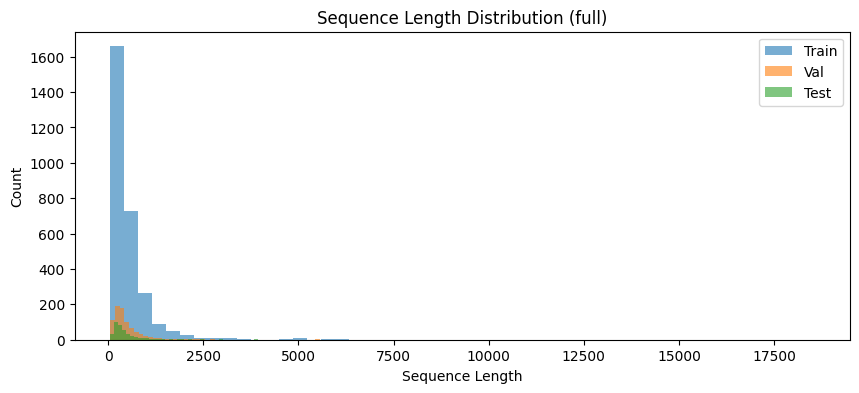

In [98]:
plt.figure(figsize=(10,4))
plt.hist(lengths_train, bins=50, alpha=0.6, label='Train')
plt.hist(lengths_val, bins=50, alpha=0.6, label='Val')
plt.hist(lengths_test, bins=50, alpha=0.6, label='Test')
#plt.xscale('log') 
plt.xlabel('Sequence Length')
plt.ylabel('Count')
plt.title('Sequence Length Distribution (full)')
plt.legend()
plt.savefig(os.path.join(PLOT_DIR, 'seq_length_distribution_full_oh.png'))
plt.show()

Min length: 40, Max length  18559


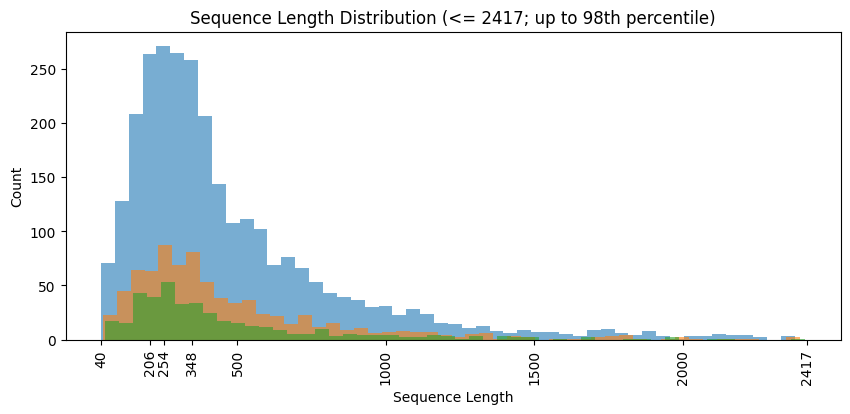

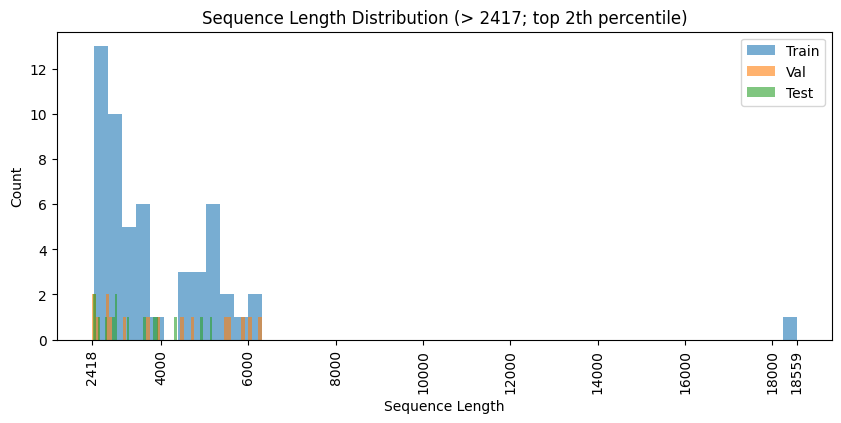

In [ ]:
q = 98 # Show up to 99th percentile
max_length = np.percentile(np.concatenate([lengths_train, lengths_val, lengths_test]), q)
min_length = min(np.concatenate([lengths_train, lengths_val, lengths_test]))
max_length_overall = max(np.concatenate([lengths_train, lengths_val, lengths_test]))
print(f"Min length: {min_length}, Max length  {max_length_overall}")
plt.figure(figsize=(10,4))
n_bins = 50
min_dist = 30

# Plot histograms
plt.hist(lengths_train[lengths_train <= max_length], bins=n_bins, alpha=0.6, label='Train')
plt.hist(lengths_val[lengths_val <= max_length], bins=n_bins, alpha=0.6, label='Val')
plt.hist(lengths_test[lengths_test <= max_length], bins=n_bins, alpha=0.6, label='Test')

# Add more xticks where distribution is high
counts, bin_edges = np.histogram(np.concatenate([
    lengths_train[lengths_train <= max_length],
    lengths_val[lengths_val <= max_length],
    lengths_test[lengths_test <= max_length]
]), bins=n_bins)
threshold = np.percentile(counts, 95)  # Top 5% bins
high_bins = np.where(counts >= threshold)[0]
bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])

# Get current xticks and add new ones with minimum distance constraint
current_xticks = list(plt.xticks()[0])
new_ticks = list(bin_centers[high_bins])

# Filter ticks to maintain minimum distance
min_distance = (max_length - min_length) / 200  # Ensure reasonable spacing
all_ticks = current_xticks + new_ticks
all_ticks = [tick for tick in all_ticks if tick >= min_length and tick <= max_length]
all_ticks = sorted(set(np.round(all_ticks).astype(int)))

# Keep ticks that are sufficiently spaced apart
filtered_ticks = [all_ticks[0]] if all_ticks else []
for tick in all_ticks[1:]:
    if tick - filtered_ticks[-1] >= min_distance:
        filtered_ticks.append(tick)
# Only add min_length if far enough from nearest tick
if filtered_ticks:
    if all(abs(int(min_length) - t) >= min_distance for t in filtered_ticks):
        filtered_ticks = [int(min_length)] + filtered_ticks
    if all(abs(int(max_length) - t) >= min_distance for t in filtered_ticks):
        filtered_ticks.append(int(max_length))
plt.xticks(filtered_ticks, rotation=90)

plt.xlabel('Sequence Length')
plt.ylabel('Count')
plt.title(f'Sequence Length Distribution (<= {int(max_length)}; up to {q}th percentile)')
plt.savefig(os.path.join(PLOT_DIR, f'seq_length_distribution_le_{int(max_length)}_oh.png'))

# for the rest 100 - q % 
plt.figure(figsize=(10,4))
plt.hist(lengths_train[lengths_train > max_length], bins=50, alpha=0.6, label='Train')
plt.hist(lengths_val[lengths_val > max_length], bins=50, alpha=0.6, label='Val')
plt.hist(lengths_test[lengths_test > max_length], bins=50, alpha=0.6, label='Test')

# Add min and max length as ticks for the tail plot, but only if far enough from other ticks
current_xticks_tail = list(plt.xticks()[0])
min_tail = int(np.min(lengths_train[lengths_train > max_length].tolist() + lengths_val[lengths_val > max_length].tolist() + lengths_test[lengths_test > max_length].tolist() or [max_length+1]))
max_tail = int(max_length_overall)
filtered_ticks_tail = sorted(set([int(tick) for tick in current_xticks_tail if tick >= min_tail and tick <= max_tail]))
# Only add min_tail if far enough from nearest tick
if filtered_ticks_tail:
    if all(abs(int(min_tail) - t) >= min_distance for t in filtered_ticks_tail):
        filtered_ticks_tail = [int(min_tail)] + filtered_ticks_tail
    if all(abs(int(max_tail) - t) >= min_distance for t in filtered_ticks_tail):
        filtered_ticks_tail.append(int(max_tail))
else:
    filtered_ticks_tail = [int(min_tail), int(max_tail)]
plt.xticks(filtered_ticks_tail, rotation=90)

plt.xlabel('Sequence Length')
plt.ylabel('Count')
plt.title(f'Sequence Length Distribution (> {int(max_length)}; top {100-q}th percentile)')
plt.legend()
plt.savefig(os.path.join(PLOT_DIR, f'seq_length_distribution_gt_{int(max_length)}_oh.png'))
plt.show()

TODO: in the end also analyze if how well th emodels predict short (<1), medium, long length sequences well! 

## Plot label / class  Venn Diagram colored by Train / Val / Test 

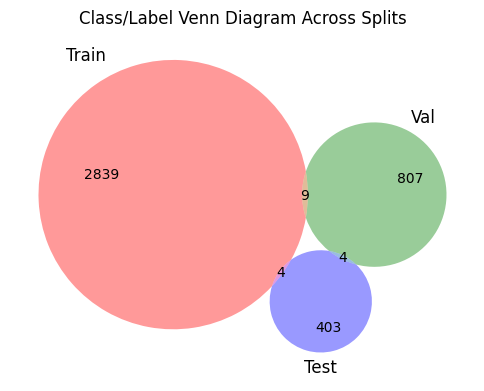

In [ ]:
# Plot label / class distribution Venn Diagram colored by Train / Val / Test
from matplotlib_venn import venn3

# Get unique labels/classes in each split (residue-level)
labels_train = set(train_dataset_oh.df['label'])
labels_val = set(val_dataset_oh.df['label'])
labels_test = set(test_dataset_oh.df['label'])

plt.figure(figsize=(6,6))
venn3([labels_train, labels_val, labels_test], set_labels=('Train', 'Val', 'Test'))
plt.title("Class/Label Venn Diagram Across Splits")
plt.savefig(os.path.join(PLOT_DIR, 'class_label_venn_oh.png'))
plt.show()

### extract the classes that are only in test set (for later analysis regarding predicitons)

In [13]:
labels_only_in_test = labels_test - labels_train - labels_val
print(f"Classes only in test set ({len(labels_only_in_test)}): {sorted(labels_only_in_test)}")

Classes only in test set (403): ['PF00001.26-133-402', 'PF00001.26-22-294', 'PF00001.26-35-278', 'PF00001.26-54-304', 'PF00002.29-463-710', 'PF00003.28-361-629', 'PF00004.35-186-315', 'PF00005.33-51-220', 'PF00207.28-120-194', 'PF00207.28-701-792', 'PF00330.25-391-526', 'PF00389.36-8-344', 'PF00393.24-103-170', 'PF00441.29-32-179', 'PF00561.26-145-523', 'PF00583.31-17-145', 'PF00583.31-24-151', 'PF00664.28-25-305', 'PF00664.28-79-354', 'PF00664.28-912-1177', 'PF00696.33-400-630', 'PF00797.23-55-293', 'PF00803.23-7-206', 'PF00803.23-7-221', 'PF00873.25-3-504', 'PF00873.25-553-1125', 'PF00887.24-7-80', 'PF01064.29-53-133', 'PF01257.25-228-307', 'PF01490.24-116-338', 'PF01490.24-61-465', 'PF01643.23-24-147', 'PF01648.25-119-222', 'PF01648.25-81-180', 'PF01812.26-59-266', 'PF01842.31-363-433', 'PF01989.22-37-117', 'PF02096.25-62-245', 'PF02096.25-90-301', 'PF02117.22-1-79', 'PF02175.22-221-339', 'PF02175.22-378-574', 'PF02230.22-10-220', 'PF02230.22-25-256', 'PF02496.21-126-175', 'PF02496.

## Class distribution / frequency => to analyze for inbalance in dataset (how much more is class 0 present?)

In [94]:
all_oh_df.columns

Index(['AC', 'label', 'start', 'end', 'length', 'header', 'sequence', 'split'], dtype='object')

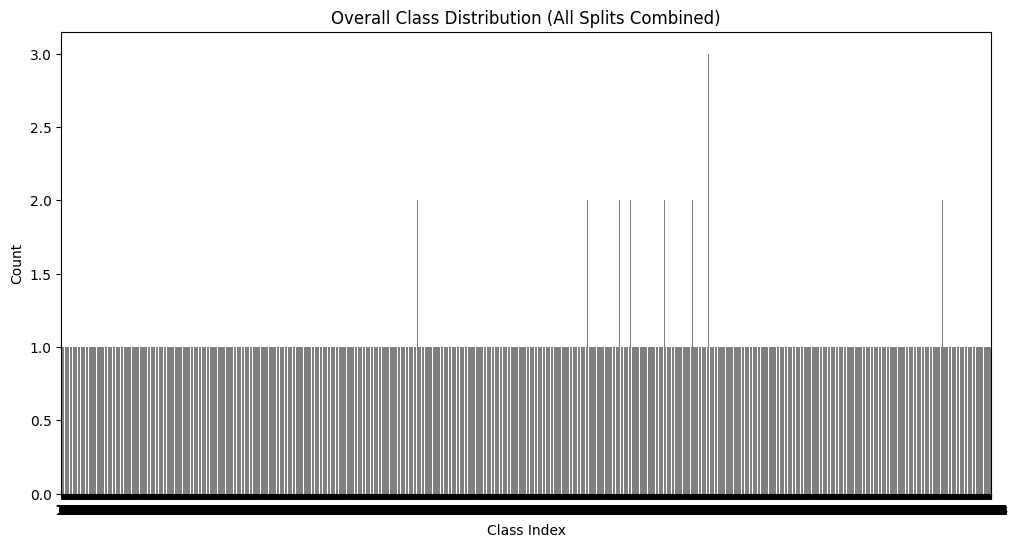

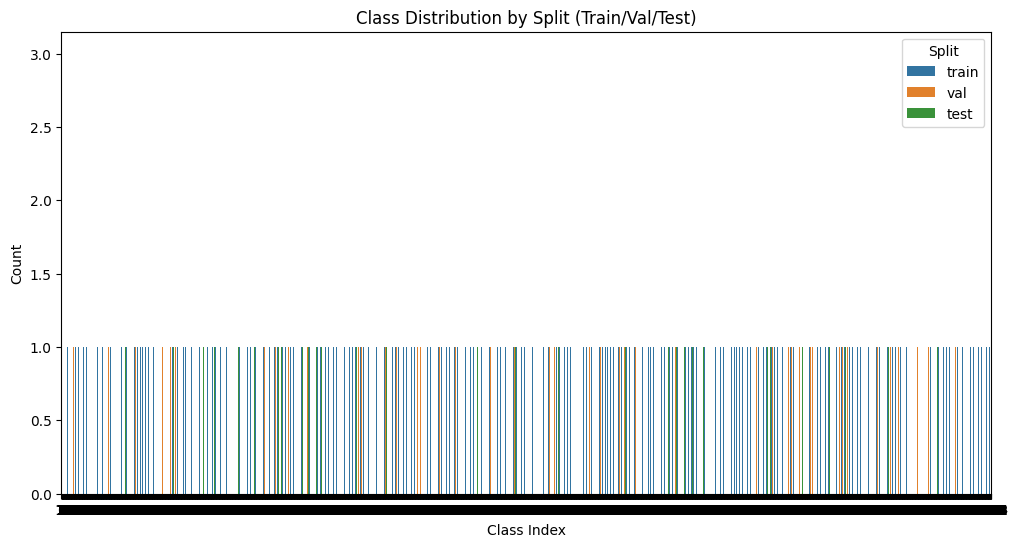

In [99]:
# Plot class distribution for all data 
plt.figure(figsize=(12,6))
sns.countplot(data=all_oh_df, x='label', order=sorted(all_oh_df['label'].unique()), color='gray')
plt.xlabel('Class Index')
plt.ylabel('Count')
plt.title('Overall Class Distribution (All Splits Combined)')
plt.xticks(ticks=range(len(sorted(all_oh_df['label'].unique()))), labels=range(len(sorted(all_oh_df['label'].unique()))))
plt.savefig(os.path.join(PLOT_DIR, 'class_distribution_all_oh.png'))
plt.show()

# Plot class distribution colored by split (train/val/test)
plt.figure(figsize=(12,6))
sns.countplot(data=all_oh_df, x='label', hue='split', order=sorted(all_oh_df['label'].unique()))
plt.xlabel('Class Index')
plt.ylabel('Count')
plt.title('Class Distribution by Split (Train/Val/Test)')
plt.legend(title='Split')
plt.xticks(ticks=range(len(sorted(all_oh_df['label'].unique()))), labels=range(len(sorted(all_oh_df['label'].unique()))))
plt.savefig(os.path.join(PLOT_DIR, 'class_distribution_by_split_oh.png'))
plt.show()

C:\Users\dgars\AppData\Local\Temp\ipykernel_7864\1925790881.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=percentages.index, y=percentages.values, palette='viridis')


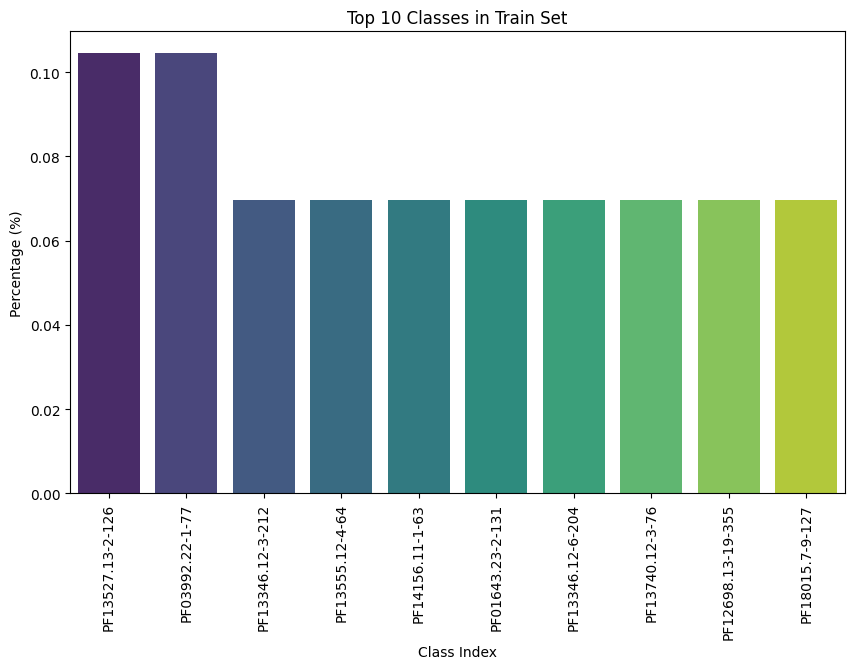

C:\Users\dgars\AppData\Local\Temp\ipykernel_7864\1925790881.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=percentages.index, y=percentages.values, palette='viridis')


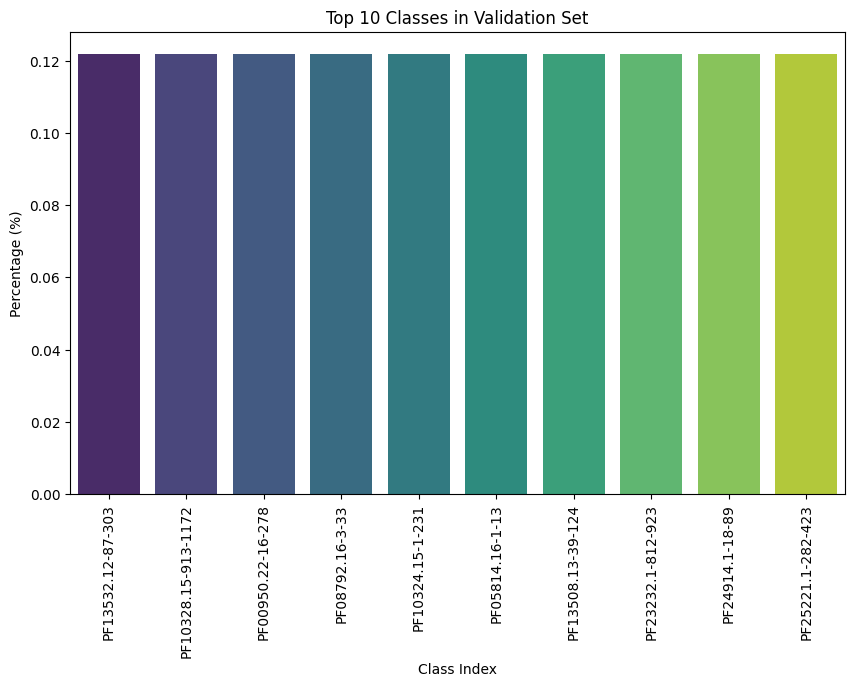

C:\Users\dgars\AppData\Local\Temp\ipykernel_7864\1925790881.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=percentages.index, y=percentages.values, palette='viridis')


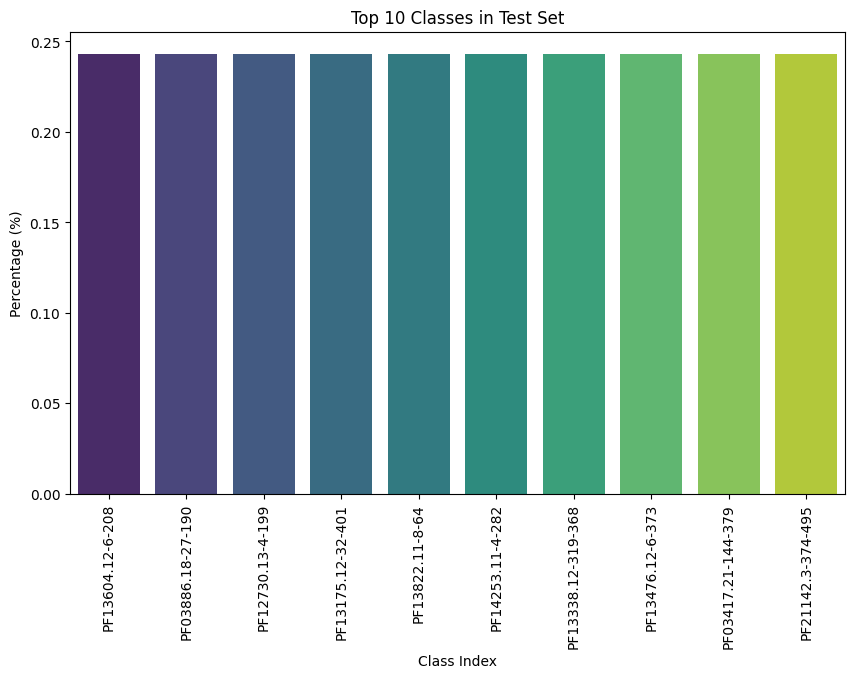

C:\Users\dgars\AppData\Local\Temp\ipykernel_7864\1925790881.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=percentages.index, y=percentages.values, palette='viridis')


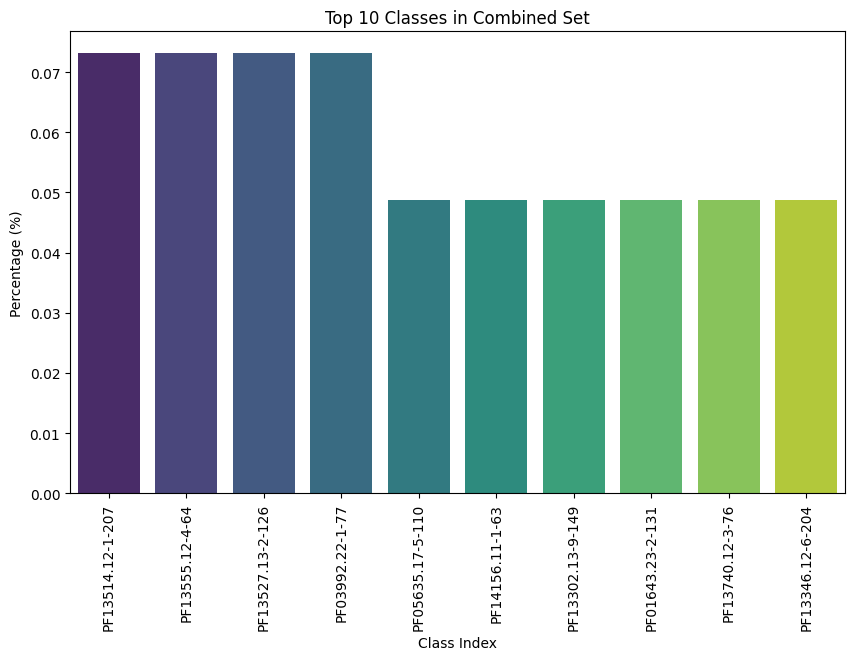

In [ ]:
# plot percentage of top 10 classes in train, val, test and combined 
def plot_top_classes(df, split_name, top_n=10):
    # Get class counts
    class_counts = df['label'].value_counts().head(top_n)
    
    # Calculate percentages
    total_count = df.shape[0]
    percentages = (class_counts / total_count) * 100
    
    # Plot
    plt.figure(figsize=(10, 6))
    sns.barplot(x=percentages.index, y=percentages.values, palette='viridis')
    plt.xlabel('Class Index')
    plt.ylabel('Percentage (%)')
    plt.title(f'Top {top_n} Classes in {split_name} Set')
    plt.xticks(rotation=90)
    plt.savefig(os.path.join(PLOT_DIR, f'top_{top_n}_classes_{split_name}_oh.png'))
    plt.show()
    
plot_top_classes(train_df, 'Train')
plot_top_classes(val_df, 'Validation')
plot_top_classes(test_df, 'Test')
plot_top_classes(all_oh_df, 'Combined')

## 4. Obtain Model Predictions and Probabilities (Softmax)
Run inference on train and validation sets for both models. Apply softmax to outputs to get class probabilities.

In [ ]:
def get_probs_and_labels(model, loader, device='cpu'):
    model.to(device)
    all_probs, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            inputs = batch['embeddings'].to(device)
            labels = batch['labels'].to(device)
            logits, _ = model(inputs)
            probs = F.softmax(logits, dim=-1)
            # Flatten batch and sequence dims
            all_probs.append(probs.cpu().numpy().reshape(-1, probs.shape[-1]))
            all_labels.append(labels.cpu().numpy().reshape(-1, labels.shape[-1]))
    all_probs = np.concatenate(all_probs, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    return all_probs, all_labels

In [ ]:
# Combine train and val for threshold search for each model
combined_dataset_oh = ConcatDataset([train_dataset_oh, val_dataset_oh])  
combined_loader_oh = DataLoader(combined_dataset_oh, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn_window)

probs_oh, labels_oh = get_probs_and_labels(model1, combined_loader_oh)

In [ ]:
# save incase kernel crashes or for later analysis
combined_dataset_oh = ConcatDataset([train_dataset_oh, val_dataset_oh])  
combined_loader_oh = DataLoader(combined_dataset_oh, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn_window)

probs_oh, labels_oh = get_probs_and_labels(model3, combined_loader_oh)

import numpy as np

np.save("probs_oh_2.npy", probs_oh)
np.save("labels_oh_2.npy", labels_oh)

In [ ]:
combined_dataset_emb = ConcatDataset([train_dataset_emb, val_dataset_emb])
combined_loader_emb = DataLoader(combined_dataset_emb, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn_window)

probs_emb, labels_emb = get_probs_and_labels(model2, combined_loader_emb)

In [ ]:
# save incase kernel crashes or for later analysis
import numpy as np

np.save("probs_emb.npy", probs_emb)
np.save("labels_emb.npy", labels_emb)
print("Saved probs_emb.npy and labels_emb.npy")

## 5. Find Optimal Threshold on Train & Validation Sets
Use grid search to find the optimal probability threshold for classification, **maximizing MACRO F1-score.** 

MacroF1 calculates the F1 for each class independently and then averages them, giving equal weight to all classes, regardless of how many samples each class has.  => we have lots of 0 labels => inbalanced , but maybe try micro aswell

In [ ]:
from sklearn.metrics import f1_score

def find_best_threshold(probs, labels, metric=f1_score):
    best_thr, best_score = 0.5, 0
    y_true = labels.argmax(axis=-1).flatten()
    for thr in np.linspace(0.1, 0.9999, 18):
        y_pred = probs.argmax(axis=-1)
        mask = probs.max(axis=-1) >= thr
        y_pred_thr = np.where(mask, y_pred, -1)
        valid = y_pred_thr != -1
        if valid.sum() == 0:
            continue
        score = metric(y_true[valid], y_pred_thr[valid], average='macro')
        if score > best_score:
            best_score = score
            best_thr = thr
    return best_thr, best_score

best_thr_oh, best_f1_oh = find_best_threshold(probs_oh, labels_oh)
#best_thr_emb, best_f1_emb = find_best_threshold(probs_emb, labels_emb)
print(f"Model1 (OneHot) best threshold: {best_thr_oh:.2f}, F1: {best_f1_oh:.4f}")
#print(f"Model2 (Embedding) best threshold: {best_thr_emb:.2f}, F1: {best_f1_emb:.4f}")

## 6. Evaluate Per-Class Metrics (Accuracy, Precision, Recall, F1) on Test Set
Calculate per-class accuracy, precision, recall, and F1-score for both models on the test set using the optimal threshold found from train+val.

In [ ]:
probs_oh_test, labels_oh_test  = probs_oh, labels_oh  # DEV ONLY
probs_oh_test, labels_oh_test = get_probs_and_labels(model3, test_loader_oh)
#probs_oh_test, labels_oh_test = get_probs_and_labels(model1, test_loader_oh)
#probs_emb_test, labels_emb_test = get_probs_and_labels(model2, test_loader_emb)

In [ ]:
probs_oh_test[0]

In [ ]:
# TODO REMOVE THRESHOLD!
def per_class_metrics(probs, labels, threshold):
    y_true = labels.argmax(axis=-1).flatten()
    y_pred = probs.argmax(axis=-1)
    mask = probs.max(axis=-1) >= threshold
    y_pred_thr = np.where(mask, y_pred, -1)
    valid = y_pred_thr != -1
    report = classification_report(y_true[valid], y_pred_thr[valid], output_dict=True)
    return report

# TODO REMOVE THRESHOLD!
report_oh_test = per_class_metrics(probs_oh_test, labels_oh_test, best_thr_oh)
#report_emb_test = per_class_metrics(probs_emb_test, labels_emb_test, best_thr_emb)
print("Model1 (OneHot) Test classification report:")
display(pd.DataFrame(report_oh_test).T)
#print("Model2 (Embedding) Test classification report:")
#display(pd.DataFrame(report_emb_test).T)

- Precision: For each class, precision is the proportion of predicted positives that are actually correct. High precision means few false positives.
- Recall: For each class, recall is the proportion of actual positives that are correctly identified. High recall means few false negatives.
- F1-score: The harmonic mean of precision and recall for each class. It balances both metrics; high only if both precision and recall are high.
- Support: The number of true instances for each class in the dataset (how many times each class appears).

On the y-axis are all classes for which the model predicted something - seeing UndefinedMetricWarning means that the model didnt predict some classes.

## 7. Test Set Evaluation: Predictions and Metrics
Run inference on the test set for both models. Compute accuracy, precision, recall, F1-score (macro), and confusion matrix at the residue level.

In [ ]:
def test_metrics(probs, labels, threshold):
    y_true = labels.argmax(axis=-1).flatten()
    y_pred = probs.argmax(axis=-1)
    mask = probs.max(axis=-1) >= threshold
    y_pred_thr = np.where(mask, y_pred, -1)
    valid = y_pred_thr != -1
    acc = accuracy_score(y_true[valid], y_pred_thr[valid])
    prec = precision_score(y_true[valid], y_pred_thr[valid], average='macro', zero_division=0)
    rec = recall_score(y_true[valid], y_pred_thr[valid], average='macro', zero_division=0)
    f1 = f1_score(y_true[valid], y_pred_thr[valid], average='macro', zero_division=0)
    cm = confusion_matrix(y_true[valid], y_pred_thr[valid])
    return acc, prec, rec, f1, cm

acc_oh, prec_oh, rec_oh, f1_oh, cm_oh = test_metrics(probs_oh_test, labels_oh_test, best_thr_oh)
#acc_emb, prec_emb, rec_emb, f1_emb, cm_emb = test_metrics(probs_emb_test, labels_emb_test, best_thr_emb)
print(f"Model1 (OneHot) Test - Acc: {acc_oh:.4f}, Prec: {prec_oh:.4f}, Rec: {rec_oh:.4f}, F1: {f1_oh:.4f}")
#print(f"Model2 (Embedding) Test - Acc: {acc_emb:.4f}, Prec: {prec_emb:.4f}, Rec: {rec_emb:.4f}, F1: {f1_emb:.4f}")

## 8. Measure Inference Runtime and GPU Usage
Measure inference time using time.perf_counter() and GPU memory usage with tracemalloc.get_traced_memory() for both models on the test set.

In [ ]:
def measure_inference_time_and_memory(model, loader, threshold, device='cpu'):
    model.to(device)
    tracemalloc.start()
    start = time.perf_counter()
    with torch.no_grad():
        for batch in loader:
            inputs = batch['embeddings'].to(device)
            logits, _ = model(inputs)
            _ = F.softmax(logits, dim=-1)
    end = time.perf_counter()
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return end - start, peak / 1e6  # seconds, MB

time_oh, mem_oh = measure_inference_time_and_memory(model3, test_loader_oh, best_thr_oh)
#time_emb, mem_emb = measure_inference_time_and_memory(model2, test_loader_emb, best_thr_emb)
print(f"Model1 (OneHot) inference time: {time_oh:.2f}s, peak memory: {mem_oh:.2f}MB")
#print(f"Model2 (Embedding) inference time: {time_emb:.2f}s, peak memory: {mem_emb:.2f}MB")

## 9. Calculate Model Size (Number of Parameters)
Count and display the number of trainable parameters for each model.

In [ ]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

#print(f"Model1 (OneHot) parameters: {count_parameters(model1):,}")
#print(f"Model2 (Embedding) parameters: {count_parameters(model2):,}")
print(f"Model3 (OneHot) parameters: {count_parameters(model3):,}")

## 10. Compute Confusion Matrix for Residue-Level Predictions
Plot and analyze confusion matrices for residue-level predictions for both models.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm_oh, annot=True, fmt='d', ax=axes[0], cmap='Blues')
axes[0].set_title('Model1 (OneHot) Confusion Matrix')
#sns.heatmap(cm_emb, annot=True, fmt='d', ax=axes[1], cmap='Greens')
#axes[1].set_title('Model2 (Embedding) Confusion Matrix')
plt.savefig(os.path.join(PLOT_DIR, 'confusion_matrix_oh.png'))
plt.show()

## 11. Domain-Level Prediction Evaluation
Compare predicted domains with annotated domains in the test set and evaluate domain-level accuracy. This typically involves grouping residue-level predictions into domains and comparing them to annotated domain boundaries.

**Suggestions:**
- Define a function to extract domains from residue-level predictions (e.g., consecutive residues with the same label).
- Compare predicted domains to true domains using overlap, Jaccard index, or boundary accuracy.
- Compute domain-level precision, recall, and F1-score.

In [ ]:
probs_oh

In [ ]:
def extract_domains(labels, min_length=2):
    """Extract domain regions from a sequence of labels.
    Only keep domains of length >= min_length.
    Returns a list of (label, start, end) tuples.
    """
    domains = []
    current_label = None
    start = 0
    for i, label in enumerate(labels):
        if label != current_label:
            if current_label is not None:
                if i - start >= min_length:
                    domains.append((current_label, start, i-1))
            current_label = label
            start = i
    # Add last domain
    if len(labels) - start >= min_length:
        domains.append((current_label, start, len(labels)-1))
    return domains

In [ ]:
# Convert one-hot/probabilities to class indices for the whole sequence
y_true_seq = labels_oh.argmax(axis=-1)  
y_pred_seq = probs_oh.argmax(axis=-1)   

y_true_seq_emb = labels_emb.argmax(axis=-1)  
y_pred_seq_emb = probs_emb.argmax(axis=-1)   

# Extract domains from the entire sequence
min_length = 2
true_domains = extract_domains(y_true_seq, min_length=min_length)
pred_domains = extract_domains(y_pred_seq, min_length=min_length)
print("OneHot Model Domains:")
print(f"Extracted {len( true_domains)} true domains with {min_length} :", true_domains) 
print(f"Extracted {len( pred_domains)} predicted domains with {min_length}:", pred_domains)

# Extract domains from the embedding model
true_domains_emb = extract_domains(y_true_seq_emb, min_length=min_length)
pred_domains_emb = extract_domains(y_pred_seq_emb, min_length=min_length)
print("Embedding Model Domains:")
print(f"Extracted {len(true_domains_emb)} true domains with {min_length} :", true_domains_emb)
print(f"Extracted {len(pred_domains_emb)} predicted domains with {min_length}:", pred_domains_emb)

## 12. Analyze Confusion Patterns Between Protein Families
Compute and visualize confusion matrices for actual vs predicted protein families. Analyze common confusion patterns.

**Suggestions:**
- Ensure your dataset includes a family label for each protein.
- Aggregate predictions at the protein level (e.g., majority vote or max probability for each protein).
- Compute a confusion matrix using true and predicted family labels.
- Visualize the confusion matrix and highlight common confusions.

In [ ]:
# Example structure for family-level confusion matrix
# Assume you have lists: true_families, pred_families (one per protein)
from sklearn.metrics import confusion_matrix

# true_families = [...]  # List of true family labels for each protein
# pred_families = [...]  # List of predicted family labels for each protein
# family_names = [...]   # List of all family names (for axis labels)

# cm_family = confusion_matrix(true_families, pred_families, labels=family_names)
# plt.figure(figsize=(8,6))
# sns.heatmap(cm_family, annot=True, fmt='d', xticklabels=family_names, yticklabels=family_names, cmap='Purples')
# plt.xlabel('Predicted Family')
# plt.ylabel('True Family')
# plt.title('Family-level Confusion Matrix')
# plt.show()

print("Family-level confusion analysis: Fill true_families and pred_families, then use the above code to visualize and analyze confusion patterns.")

To save the model to html with cell outputs run 'jupyter nbconvert --to html EVAL_ProteinModel_Comparison.ipynb'